This is a script to create STL files for 3D printing Greenland, with the ultimate goal of printing a removable ice layer and a separate ice base/bathymetry. 

A process has been successfully implemented previously, but documentation and software are out of date.  We aim to create a repeatable process that can be applied to all DEM data (in Geotiff form). A lot of this code was copied from various parts of the internet.

In general, the procedure here is: 

1) Import Packages and define functions
2) Process the surface and base data so that they are clipped to the ice extent, and standardize the "no data value" so that the area outside the mask is set to the same value. Export these processed files as their own geotiffs.
3) Run the function and export the STLs

This script takes raster DEM data and a clipping mask shapefile as inputs and outputs stls.  The input rasters must be downsampled to the desired resolution prior to running the script. This can be done in QGIS. The recommended cell size is at least 50 km. Anything finer will result in a model that is difficult to work with in Blender, and can be too detailed to 3D print (although the threshold for this should be tested).

In [1]:
# Import packages

#for changing directories
import os  

#for raster functions - this gets called in the defined function below
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.enums import Resampling #this may not be needed

#for array functions - this gets called in the defined function below
import numpy as np

#for clipping with a shapefile
import fiona

#for visualizations - this may not be necessary
import trimesh
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import meshlib.mrmeshpy as mr
from meshlib import mrmeshnumpy as mn
import plotly.graph_objects as go

We define a function, geotiff_to_stl_f, based on Isabel's geotiff_to_stl function.  The main difference is the way the raster gets imported. Alex found that the original function read in the raster "backwards" so that the output was mirror imaged.

In [2]:
def geotiff_to_stl_f(input_tif, output_stl, scale_factor, vertical_exaggeration):
    # Load elevation data
    with rasterio.open(input_tif) as src:
        elevation_in = src.read(1)
        transform_in = src.transform
        
        flipped = elevation_in[::-1, :]
        flipped_transform = rasterio.Affine(
            transform_in.a, transform_in.b, transform_in.c,
            transform_in.d, transform_in.e, transform_in.f + src.height * transform_in.e)
        
        elevation = flipped
        transform = transform_in    
        

    # Handle NoData
    elevation = np.nan_to_num(elevation, nan=np.nanmin(elevation))

    # Downsample for smaller STL
    elevation = zoom(elevation, scale_factor)

    # Dimensions
    n_rows, n_cols = elevation.shape

    # Generate X, Y grid
    x = np.arange(n_cols)
    y = np.arange(n_rows)
    x, y = np.meshgrid(x, y)

    # Scale Z
    z = elevation * vertical_exaggeration

    # Flatten grid
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))

    # Build faces (2 triangles per square cell)
    faces = []
    for i in range(n_rows - 1):
        for j in range(n_cols - 1):
            idx = i * n_cols + j
            faces.append([idx, idx + 1, idx + n_cols])
            faces.append([idx + 1, idx + n_cols + 1, idx + n_cols])

    # Create terrain mesh
    terrain = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
    
    if flat_bottom == 1:
        # Build flat bottom (Z = base level)
        flat_z = np.min(z)
        base_vertices = np.column_stack((x.flatten(), y.flatten(), np.full_like(z.flatten(), flat_z)))

        # Side walls between terrain and base
        skirt_faces = []
        skirt_vertices = []
        def add_wall(v_top1, v_top2, v_bot1, v_bot2):
            idx = len(skirt_vertices)
            skirt_vertices.extend([v_top1, v_top2, v_bot1, v_bot2])
            skirt_faces.extend([
                [idx, idx+1, idx+2],
                [idx+1, idx+3, idx+2]
            ])

        # Edges
        for i in range(n_rows - 1):
            top1 = vertices[i * n_cols]
            top2 = vertices[(i + 1) * n_cols]
            bot1 = base_vertices[i * n_cols]
            bot2 = base_vertices[(i + 1) * n_cols]
            add_wall(top1, top2, bot1, bot2)  # left edge

            top1 = vertices[i * n_cols + n_cols - 1]
            top2 = vertices[(i + 1) * n_cols + n_cols - 1]
            bot1 = base_vertices[i * n_cols + n_cols - 1]
            bot2 = base_vertices[(i + 1) * n_cols + n_cols - 1]
            add_wall(top1, top2, bot1, bot2)  # right edge

        for j in range(n_cols - 1):
            top1 = vertices[j]
            top2 = vertices[j + 1]
            bot1 = base_vertices[j]
            bot2 = base_vertices[j + 1]
            add_wall(top1, top2, bot1, bot2)  # top edge

            top1 = vertices[(n_rows - 1) * n_cols + j]
            top2 = vertices[(n_rows - 1) * n_cols + j + 1]
            bot1 = base_vertices[(n_rows - 1) * n_cols + j]
            bot2 = base_vertices[(n_rows - 1) * n_cols + j + 1]
            add_wall(top1, top2, bot1, bot2)  # bottom edge

        # Flat bottom face (optional for fully closed mesh)
        flat_faces = []
        for i in range(n_rows - 1):
            for j in range(n_cols - 1):
                idx = i * n_cols + j
                flat_faces.append([idx, idx + n_cols, idx + 1])
                flat_faces.append([idx + 1, idx + n_cols, idx + n_cols + 1])

        base = trimesh.Trimesh(vertices=base_vertices, faces=flat_faces, process=False)
        skirt = trimesh.Trimesh(vertices=np.array(skirt_vertices), faces=np.array(skirt_faces), process=False)

        # Combine terrain + side skirts + flat bottom
        combined = trimesh.util.concatenate([terrain, skirt, base])
    else:
        # Create side walls (non-flat bottom)
        bottom_z = np.min(z)
        skirt_vertices = []
        skirt_faces = []
    
        def add_wall(p1, p2):
            idx = len(skirt_vertices)
            skirt_vertices.extend([
                [p1[0], p1[1], p1[2]],
                [p2[0], p2[1], p2[2]],
                [p1[0], p1[1], bottom_z],
                [p2[0], p2[1], bottom_z]
            ])
            skirt_faces.extend([
                [idx, idx+1, idx+2],
                [idx+1, idx+3, idx+2]
            ])
    
        # Edges: left, right, top, bottom
        for i in range(n_rows - 1):
            add_wall(vertices[i*n_cols], vertices[(i+1)*n_cols])  # left
            add_wall(vertices[i*n_cols + n_cols - 1], vertices[(i+1)*n_cols + n_cols - 1])  # right
        for j in range(n_cols - 1):
            add_wall(vertices[j], vertices[j+1])  # top
            add_wall(vertices[(n_rows-1)*n_cols + j], vertices[(n_rows-1)*n_cols + j + 1])  # bottom
    
        # Bottom face (close mesh)
        bottom_vertices = [
            [0, 0, bottom_z],
            [0, n_rows - 1, bottom_z],
            [n_cols - 1, n_rows - 1, bottom_z],
            [n_cols - 1, 0, bottom_z]
        ]
        bottom_faces = [
            [0, 1, 2],
            [0, 2, 3]
        ]
        bottom_mesh = trimesh.Trimesh(vertices=bottom_vertices, faces=bottom_faces)
    
        # Combine terrain + skirt + bottom
        skirt_mesh = trimesh.Trimesh(vertices=np.array(skirt_vertices), faces=np.array(skirt_faces), process=False)
        combined = trimesh.util.concatenate([terrain, skirt_mesh, bottom_mesh])
        

    # Optional: Simplify (decimate) mesh
    #combined = combined.simplify_quadric_decimation(int(len(combined.faces) * 0.3))  # Keep 30%

    # Export to STL
    combined.export(output_stl)
    print(f"STL saved to {output_stl}")

Now we process Bed data.  The ice mask shapefile that we use was processed in QGIS from the GIMP dataset to lower the vertex count and to remove holes in the mask.  


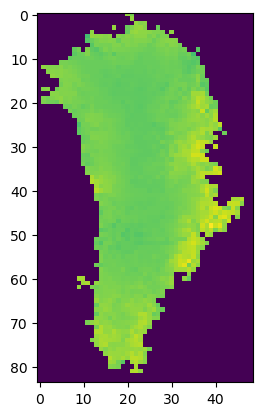

<Axes: >

In [4]:
# Process Bed data

# Import files
inshp='/path/to/file/GIMPIceMask10km.shp' 
inRas="/path/to/file/Bed_Downsample_30000.tif"
output_raster_path="/path/to/file/bed_downsampled_raster_clipped_dec9.tif"

# Open the shapefile with fiona
with fiona.open(inshp, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

# Perform the clipping, set the no data value to -9999 with crop=TRUE. This is what defines the value outside the mask
with rasterio.open(inRas) as src:
    out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True,nodata=-9999)
    out_meta = src.meta

# Update the metadata and write
out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform})
with rasterio.open(output_raster_path, "w", **out_meta) as dest:
    dest.write(out_image)

# Check that it looks right - this can be improved later! Would potentially be nice to make a real map. 
show(out_image)

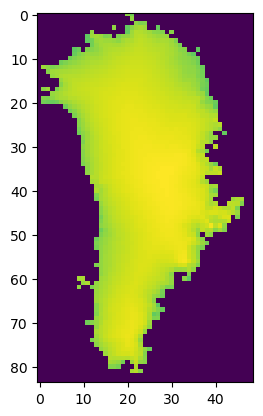

<Axes: >

In [5]:
# Process Surface data

# Import files
inshp='/path/to/file/GIMPIceMask10km.shp' 
inRas="/path/to/file/GreenlandRasterData/Downsampled/Surface_Downsample_30000.tif"
output_raster_path="/path/to/file/surface_downsampled_raster_clipped_dec9.tif"

# Open the shapefile with fiona
with fiona.open(inshp, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

# Perform the clipping, set the no data value to -9999 with crop=TRUE. This is what defines the value outside the mask
with rasterio.open(inRas) as src:
    out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True,nodata=-9999)
    out_meta = src.meta

# Update the metadata and write
out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform})
with rasterio.open(output_raster_path, "w", **out_meta) as dest:
    dest.write(out_image)

# Check that it looks right - this can be improved later! Would potentially be nice to make a real map. 
show(out_image)

Now we write the STL files

In [6]:
# set up function inputs to make the stl for the Bed
os.chdir('/path/')

input_tif='bed_downsampled_raster_clipped_dec9.tif'
output_stl='/path/to/file/bed_downsampled_raster_clipped_dec9.stl'

#Note that you technically can do the downsampling here, but it not as easy to control/see the output  
scale_factor=1  # default = 0.05 5%
vertical_exaggeration=0.01  # Stretch vertical scale (default = 1.5)

flat_bottom = 1  # 1 for flat bottom, 0 for non-flat bottom

# run function
geotiff_to_stl_f(input_tif, output_stl, scale_factor, vertical_exaggeration)

STL saved to /Users/alexandraboghosian/Documents/ScienceStuff/3D/STLs/bed_downsampled_raster_clipped_dec9.stl


In [7]:
# set up function inputs to make the stl for the Surface
os.chdir('/path/')

input_tif='surface_downsampled_raster_clipped_dec9.tif'
output_stl='/path/to/file/surface_downsampled_raster_clipped_dec9.stl'

#Note that you technically can do the downsampling here, but it not as easy to control/see the output  
scale_factor=1  # default = 0.05 5%
vertical_exaggeration=0.01  # Stretch vertical scale (default = 1.5)

flat_bottom = 1  # 1 for flat bottom, 0 for non-flat bottom

# run function
geotiff_to_stl_f(input_tif, output_stl, scale_factor, vertical_exaggeration)

STL saved to /Users/alexandraboghosian/Documents/ScienceStuff/3D/STLs/surface_downsampled_raster_clipped_dec9.stl
